# Sea-level response from ISMIP6 ice-sheet projections

This notebook extends the DTC-IS SLR framework to use **future ice-sheet projections** from the
[Ice Sheet Model Intercomparison Project for CMIP6 (ISMIP6)](https://www.climate-cryosphere.org/mips/ismip6)
as the mass balance input.

We here go from the native DTC-IS EO-data-driven approach to a purly modelling projection-framework

**Key features:**
- **Model selection:** Choose an ice-sheet model and forcing experiment via dropdown menus.
- **Projection period:** Specify the start and end years within the ISMIP6 projection window (typically 2015–2100).
- **Animation:** Visualise the spatial evolution of ice-sheet mass change over time.
- **Scenario exploration:** Apply custom scaling factors to simulate different "what-if" scenarios.
- **SLR calculation:** Feed the ISMIP6 mass balance data into the SELREM sea-level model for global and location-specific projections.

**How to use this notebook:**
1. Run the setup cells below.
2. Select an ice-sheet model and experiment, set the year range, then click **Load ISMIP6 Data**.
3. Generate the animation of cumulative ice-sheet mass change.
4. Adjust the scaling factor and explore sea-level responses globally and at chosen locations.

**Requirements:**
- Jupyter (or VS Code with the Jupyter extension).
- Internet access to the ISMIP6 object store and the DTC-IS API.

---

*ISMIP6 data are provided under their respective licences. See [ismip.org](https://www.ismip.org) for details.*

In [1]:
import sys

print("⏳ Installing dependencies...")
if "google.colab" in sys.modules:
    %pip install -q xarray zarr cartopy fsspec aiohttp s3fs==2025.3.0 ipywidgets==7.7.1
    # Ensure the newest version of the helpers package is installed
    %pip uninstall -y dtc_is_notebooks
    %pip install -q --upgrade --force-reinstall --no-deps --no-cache-dir  git+https://github.com/DTC-Ice-Sheets/dtc_is_notebooks.git

⏳ Installing dependencies...


## Notebook preparations

In [ ]:

import os
import sys
from datetime import datetime

import ipywidgets as widgets
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import HTML, clear_output, display
from matplotlib.widgets import Button

from src.dtc_is_notebook_helpers.api_helpers import (
    run_selrem_module,
    upload_mass_balance_csv,
)
from src.dtc_is_notebook_helpers.uc2_plotting_helpers import (
    MASS_BALANCE_COL_NAME,
    MASS_BALANCE_ERROR_COL_NAME,
    compute_mean_mass_balance_over_time_window,
    plot_global_slr_three_panels,
    plot_scaled_mean_mass_balance,
    plot_slr_location_four_panels,
)

os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "FALSE"
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# api_password = input("Please enter DTC-IS API password: ")
# os.environ["DTC_API_PASSWORD"] = api_password


## Select ISMIP6 model and experiment

Choose an **ice-sheet model** and a **forcing experiment** from the dropdowns below, then set
the projection years and click **Load ISMIP6 Data**.

Data are hosted on [source.coop/englacial/ismip6](https://source.coop/englacial/ismip6) as an
icechunk/zarr v3 store (no authentication required).

| Experiment | Description |
|-----------|-------------|
| exp05 | High-emissions forcing (RCP 8.5) |
| exp07 | Low-emissions forcing (RCP 2.6) |
| ctrl_proj_std | Standard control projection |


> **Note:** Not all model–experiment combinations are available. If loading fails, try a different combination.


In [4]:
# ---------------------------------------------------------------------------
# ISMIP6 configuration — data via Source Cooperative public S3 mirror
# ---------------------------------------------------------------------------
import inspect

import icechunk
import zarr

SEC_PER_YEAR = 365.25 * 24 * 3600

STORE_BUCKET         = "us-west-2.opendata.source.coop"
STORE_PREFIX         = "englacial/ismip6/icechunk-ais"
STORE_REGION         = "us-west-2"
VIRTUAL_CHUNK_PREFIX = "s3://us-west-2.opendata.source.coop/englacial/ismip6/"

model_options = [
    ("DOE / MALI",       "DOE_MALI"),
    ("AWI / PISM1",      "AWI_PISM1"),
    ("LSCE / GRISLI2",   "LSCE_GRISLI2"),
    ("NCAR / CISM",      "NCAR_CISM"),
    ("JPL / ISSM",       "JPL1_ISSM"),
]

experiment_options = [
    ("exp05 – high emissions (RCP 8.5)",   "exp05"),
    ("exp07 – low emissions (RCP 2.6)",    "exp07"),
    ("ctrl_proj_std – control projection", "ctrl_proj_std"),
]

model_dropdown = widgets.Dropdown(
    options=model_options,
    value="DOE_MALI",
    description="Ice sheet model:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="380px"),
)
experiment_dropdown = widgets.Dropdown(
    options=experiment_options,
    value="exp05",
    description="Experiment:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="380px"),
)
start_year_widget = widgets.IntText(
    value=2015, description="Start year:", style={"description_width": "initial"}
)
end_year_widget = widgets.IntText(
    value=2100, description="End year:", style={"description_width": "initial"}
)

load_button = widgets.Button(description="Load ISMIP6 Data", button_style="success")
load_output = widgets.Output()
load_status = widgets.Label(value="")

# Module-level state shared with downstream cells
mb_annual   = None
lat_2d      = None
lon_2d      = None
dataset_url = None
mean_mb_ds  = None
start_time  = None
end_time    = None
mass_balance_ds = None


def _anonymous_s3_storage_kwargs() -> dict[str, object]:
    """Build kwargs for anonymous S3 access across icechunk 1.x APIs."""
    storage_kwargs: dict[str, object] = {
        "bucket": STORE_BUCKET,
        "prefix": STORE_PREFIX,
        "region": STORE_REGION,
    }
    s3_storage_params = inspect.signature(icechunk.s3_storage).parameters

    if "anonymous" in s3_storage_params:
        storage_kwargs["anonymous"] = True
    elif "credentials" in s3_storage_params and hasattr(icechunk, "s3_anonymous_credentials"):
        storage_kwargs["credentials"] = icechunk.s3_anonymous_credentials()
    else:
        raise RuntimeError(
            "Installed icechunk does not expose a supported anonymous S3 API."
        )

    return storage_kwargs


def _virtual_chunk_credentials() -> dict[str, object] | None:
    """Authorize reads from the public Source virtual chunk container."""
    if not hasattr(icechunk, "s3_anonymous_credentials"):
        return None

    credentials_map = {
        VIRTUAL_CHUNK_PREFIX: icechunk.s3_anonymous_credentials(),
    }
    if hasattr(icechunk, "containers_credentials"):
        return icechunk.containers_credentials(credentials_map)
    return credentials_map


def _extract_lat_lon(ds: xr.Dataset) -> tuple[np.ndarray, np.ndarray]:
    """Return 2-D latitude/longitude arrays, deriving from x/y when needed."""
    for lat_name, lon_name in (("lat", "lon"), ("latitude", "longitude")):
        if lat_name in ds and lon_name in ds:
            return ds[lat_name].values, ds[lon_name].values

    if "x" in ds and "y" in ds:
        x_vals = ds["x"].values
        y_vals = ds["y"].values

        if x_vals.ndim == 1 and y_vals.ndim == 1:
            x_2d, y_2d = np.meshgrid(x_vals, y_vals)
        elif x_vals.ndim == 2 and y_vals.ndim == 2:
            x_2d, y_2d = x_vals, y_vals
        else:
            raise ValueError(
                "Unsupported x/y coordinate dimensions; expected both 1-D or both 2-D."
            )

        source_crs = ccrs.SouthPolarStereo()
        lon_lat = ccrs.PlateCarree().transform_points(source_crs, x_2d, y_2d)
        lon_2d = lon_lat[..., 0]
        lat_2d = lon_lat[..., 1]
        return lat_2d, lon_2d

    raise ValueError(
        f"Could not find geographic coordinates. Dataset variables: {list(ds.data_vars) + list(ds.coords)}"
    )


def _open_icechunk_store() -> zarr.Group:
    """Open the public ISMIP6 icechunk store and authorize its virtual chunks."""
    storage = icechunk.s3_storage(**_anonymous_s3_storage_kwargs())
    repo    = icechunk.Repository.open(
        storage=storage,
        authorize_virtual_chunk_access=_virtual_chunk_credentials(),
    )
    session = repo.readonly_session("main")
    return zarr.open_group(store=session.store, mode="r")


def _infer_cell_area(ds: xr.Dataset, mb_flux: xr.DataArray) -> xr.DataArray:
    """Return grid-cell area in m^2, using explicit area vars or inferred uniform spacing."""
    if "cell_area" in ds:
        return ds["cell_area"]
    if "areacella" in ds:
        return ds["areacella"]

    if "x" in ds and "y" in ds and ds["x"].ndim == 1 and ds["y"].ndim == 1:
        x_vals = ds["x"].values
        y_vals = ds["y"].values
        if len(x_vals) > 1 and len(y_vals) > 1:
            dx = float(np.abs(x_vals[1] - x_vals[0]))
            dy = float(np.abs(y_vals[1] - y_vals[0]))
            return xr.ones_like(mb_flux.isel(time=0), dtype=float) * (dx * dy)

    dx = 8000.0
    return xr.ones_like(mb_flux.isel(time=0), dtype=float) * (dx ** 2)


def on_load_clicked(b: Button) -> None:
    """Load ISMIP6 projection data and keep mass-balance data fully in memory."""
    global mb_annual, lat_2d, lon_2d, dataset_url, mean_mb_ds, start_time, end_time, mass_balance_ds

    model    = model_dropdown.value
    exp      = experiment_dropdown.value
    start_yr = start_year_widget.value
    end_yr   = end_year_widget.value

    if start_yr >= end_yr:
        load_status.value = "Error: Start year must be less than end year."
        return

    load_button.disabled = True
    load_status.value = f"Opening icechunk store for {model}/{exp}..."

    with load_output:
        clear_output(wait=True)
        try:
            root = _open_icechunk_store()
            group_path = None
            for grp in ("combined", "state"):
                try:
                    g = root[grp][model][exp]
                    g_keys = list(g.keys())
                    if "lithk" in g_keys and "sftgrf" in g_keys:
                        group_path = f"{grp}/{model}/{exp}"
                        break
                except KeyError:
                    continue
            if group_path is None:
                raise ValueError(
                    f"Could not find 'lithk' and 'sftgrf' in any group for {model}/{exp}."
                )
            print(f"Loading from group: {group_path}")

            ds = xr.open_zarr(
                root.store,
                group=group_path,
                consolidated=False,
            )
            print(f"Available variables: {list(ds.data_vars)}")

            RHO_ICE = 917.0
            for req in ("lithk", "sftgrf"):
                if req not in ds:
                    raise ValueError(
                        f"Required variable '{req}' not found. Available: {list(ds.data_vars)}"
                    )

            lithk = ds["lithk"]
            sftgrf = ds["sftgrf"]

            if not ({"x", "y"}.issubset(set(lithk.dims)) and "time" in lithk.dims):
                raise ValueError(
                    f"'lithk' must have (time, y, x) dims; got dims={lithk.dims}."
                )

            dH = lithk.diff("time")
            all_times = pd.DatetimeIndex(ds["time"].values)
            dt_years_vals = np.array(
                [(all_times[i + 1] - all_times[i]).days / 365.25 for i in range(len(all_times) - 1)]
            )
            dt_years_da = xr.DataArray(dt_years_vals, coords={"time": dH["time"]}, dims="time")

            dH_rate = dH / dt_years_da
            mb_flux = dH_rate * sftgrf * RHO_ICE

            nan_frac = float(np.isnan(mb_flux.isel(time=0).values).mean())
            if nan_frac > 0:
                print(
                    f"Note: mb_flux time=0 has {nan_frac:.1%} NaN cells "
                    "(missing baseline lithk at t=0; first diff step excluded)."
                )
            print(
                f"Using dH*sftgrf*rho_ice approach; "
                f"lithk shape={lithk.shape}, dH shape={dH.shape}"
            )

            area = _infer_cell_area(ds, mb_flux)
            mb_raw = mb_flux * area
            start_time = datetime(start_yr, 1, 1)
            end_time = datetime(end_yr, 12, 31)
            mb_raw = mb_raw.sel(time=slice(str(start_yr), str(end_yr)))

            time_years = pd.DatetimeIndex(mb_raw["time"].values).year
            if len(time_years) > len(time_years.unique()):
                load_status.value = "Resampling to annual resolution..."
                mb_annual = mb_raw.resample(time="1YE").mean().compute()
            else:
                load_status.value = "Loading data into memory..."
                mb_annual = mb_raw.compute()

            lat_2d, lon_2d = _extract_lat_lon(ds)
            lat_flat = lat_2d.flatten()
            lon_flat = lon_2d.flatten()

            years = mb_annual["time"].dt.year.values
            n_points = lat_flat.size
            mb_matrix = np.vstack([mb_annual.isel(time=i).values.flatten() for i in range(len(years))])
            mb_err_matrix = np.full_like(mb_matrix, np.nan, dtype=float)

            point_idx = np.arange(n_points)
            mass_balance_ds = xr.Dataset(
                {
                    MASS_BALANCE_COL_NAME: (("time", "point"), mb_matrix),
                    MASS_BALANCE_ERROR_COL_NAME: (("time", "point"), mb_err_matrix),
                },
                coords={
                    "time": pd.to_datetime(years, format="%Y"),
                    "point": point_idx,
                    "y": ("point", lat_flat),
                    "x": ("point", lon_flat),
                },
            )
            mean_mb_ds = compute_mean_mass_balance_over_time_window(
                mass_balance_ds, start_time, end_time
            )

            valid_mask = ~np.isnan(mb_matrix)
            mean_annual_gt = float(np.nansum(mb_matrix) / len(years) / 1e12)
            total_mb_gt = np.nansum(mb_matrix, axis=1) / 1e12

            print(f"Model:       {model}")
            print(f"Experiment:  {exp}")
            print(f"Years:       {years[0]} – {years[-1]}")
            print(f"Grid cells:  {int(valid_mask.any(axis=0).sum())}")
            print(f"Mean annual total MB: {mean_annual_gt:.2f} Gt/yr")
            print(
                f"Total MB range across years: {float(np.nanmin(total_mb_gt)):.2f} "
                f"to {float(np.nanmax(total_mb_gt)):.2f} Gt/yr"
            )

            dataset_url = None
            load_status.value = f"Ready (in-memory): {model} / {exp}  ({start_yr}–{end_yr})"
            print("Mass-balance data kept in memory (no CSV upload).")

        except Exception as e:
            load_status.value = f"Error: {e}"
            print(f"Failed to load ISMIP6 data: {e}")

        load_button.disabled = False


load_button.on_click(on_load_clicked)

display(
    model_dropdown, experiment_dropdown,
    start_year_widget, end_year_widget,
    load_button, load_status, load_output,
)


Dropdown(description='Ice sheet model:', layout=Layout(width='380px'), options=(('DOE / MALI', 'DOE_MALI'), ('…

Dropdown(description='Experiment:', layout=Layout(width='380px'), options=(('exp05 – high emissions (RCP 8.5)'…

IntText(value=2015, description='Start year:', style=DescriptionStyle(description_width='initial'))

IntText(value=2100, description='End year:', style=DescriptionStyle(description_width='initial'))

Button(button_style='success', description='Load ISMIP6 Data', style=ButtonStyle())

Label(value='')

Output()

## Animation: ice-sheet mass change through time

The animation below shows the **cumulative mass change** (Gt) at each grid cell, accumulated
year by year from the start of the selected projection period.

- **Blue** cells are gaining mass; **red** cells are losing mass.
- The colour scale is symmetric about zero and set from the 99th percentile of the data.
- Use the playback controls in the animation toolbar to pause, step, or scrub through time.

> Run the cell below **after** the data has loaded successfully in the cell above.

In [5]:
if mb_annual is None:
    print("Please load ISMIP6 data first using the cell above.")
else:
    # --- Convert annual mass change back to ice-thickness change [m/yr] ---
    rho_ice = 917.0
    if (
        "x" in mb_annual.coords and "y" in mb_annual.coords
        and mb_annual["x"].ndim == 1 and mb_annual["y"].ndim == 1
        and mb_annual.sizes["x"] > 1 and mb_annual.sizes["y"] > 1
    ):
        dx = float(np.abs(mb_annual["x"].values[1] - mb_annual["x"].values[0]))
        dy = float(np.abs(mb_annual["y"].values[1] - mb_annual["y"].values[0]))
        cell_area = dx * dy
    else:
        cell_area = 8000.0 ** 2

    annual_ice_m = mb_annual / (rho_ice * cell_area)
    cum_ice_m = annual_ice_m.cumsum("time")

    # --- Aggressive downsampling for speed ---
    downsample = 4
    frame_stride = 2
    cum_ice_m_ds = cum_ice_m.coarsen(y=downsample, x=downsample, boundary="trim").mean()
    lat_2d_ds = lat_2d[::downsample, ::downsample]
    lon_2d_ds = lon_2d[::downsample, ::downsample]

    frame_indices = np.arange(0, cum_ice_m_ds.sizes["time"], frame_stride)
    cum_ice_m_anim = cum_ice_m_ds.isel(time=frame_indices)
    years_anim = cum_ice_m_anim["time"].dt.year.values
    n_frames = len(years_anim)

    lat_flat = lat_2d_ds.ravel()
    lon_flat = lon_2d_ds.ravel()
    has_south = float(np.nanmin(lat_flat)) < -60
    has_north = float(np.nanmax(lat_flat)) > 60

    if has_south and not has_north:
        proj = ccrs.SouthPolarStereo()
        extent = [-180, 180, -90, -55]
        region_label = "Antarctica"
    elif has_north and not has_south:
        proj = ccrs.NorthPolarStereo()
        extent = [-180, 180, 55, 90]
        region_label = "Greenland"
    else:
        proj = ccrs.PlateCarree()
        extent = [
            float(np.nanmin(lon_flat)) - 5,
            float(np.nanmax(lon_flat)) + 5,
            float(np.nanmin(lat_flat)) - 5,
            float(np.nanmax(lat_flat)) + 5,
        ]
        region_label = "Ice sheet"

    all_vals = cum_ice_m_anim.values
    vmax = float(np.nanpercentile(np.abs(all_vals), 99))
    vmax = 1.0 if vmax == 0 else vmax
    vmin = -vmax

    model_label = model_dropdown.label
    exp_label = experiment_dropdown.label

    fig = plt.figure(figsize=(8, 6), dpi=80)
    ax = fig.add_subplot(1, 1, 1, projection=proj)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.4, color="black", zorder=3)
    ax.add_feature(cfeature.LAND, facecolor="#e0e0e0", zorder=0)
    ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", linestyle="--")

    frame_data = np.asarray(cum_ice_m_anim.values)
    mesh = ax.pcolormesh(
        lon_2d_ds,
        lat_2d_ds,
        frame_data[0],
        transform=ccrs.PlateCarree(),
        cmap="RdBu",
        vmin=vmin,
        vmax=vmax,
        shading="nearest",
        zorder=1,
    )
    title = ax.set_title(
        f"Cumulative ice thickness change — {model_label}\n"
        f"{exp_label}   |   {region_label}   |   Year {years_anim[0]}",
        fontsize=10,
    )

    cbar = fig.colorbar(mesh, ax=ax, orientation="vertical", fraction=0.04, pad=0.05)
    cbar.set_label("Cumulative ice thickness change (m)", fontsize=9)

    def _draw_frame(frame_idx: int):
        mesh.set_array(frame_data[frame_idx].ravel())
        title.set_text(
            f"Cumulative ice thickness change — {model_label}\n"
            f"{exp_label}   |   {region_label}   |   Year {years_anim[frame_idx]}"
        )
        return mesh, title

    anim = animation.FuncAnimation(
        fig,
        _draw_frame,
        frames=n_frames,
        interval=100,
        blit=False,
        repeat=True,
    )
    plt.close(fig)

    print(
        f"Rendering {n_frames}-frame cumulative-ice-thickness animation "
        f"(downsampled {downsample}x, every {frame_stride} yr, {years_anim[0]}–{years_anim[-1]})..."
    )
    display(HTML(anim.to_jshtml()))

    # Optional: save to file
    # anim.save("ismip6_ice_thickness_change.gif", writer="pillow", fps=8)


Rendering 38-frame cumulative-ice-thickness animation (downsampled 4x, every 2 yr, 2015–2089)...


## How does the projected mass input translate to sea-level change globally?

After importing, and optionally **scaling**, the projected **terrestrial mass contribution**
from the ISMIP6 ice-sheet model, we can now examine the **instantaneous Equivalent Sea Level (ESL)**.

- The **instantaneous global equivalent sea level response** is calculated based on your selected
  scaling factor and the ISMIP6 projection data.
- The **relative sea-level change** at each location accounts for local vertical deformation
  (e.g., glacial isostatic adjustment).
- **Rotational feedback** from the redistribution of water mass is included.
- The **uncertainty** reflects the SELREM model uncertainty but does **not** include the
  ice-sheet model or forcing uncertainty from ISMIP6.

---

Aggregating native 8 km pixels into 5x5 mass-conserving blocks (~40 km upload grid).


/opt/anaconda3/envs/dtc/lib/python3.12/site-packages/matplotlib/cbook.py:1719: UserWarning: Warning: converting a masked element to nan.
  return math.isfinite(val)


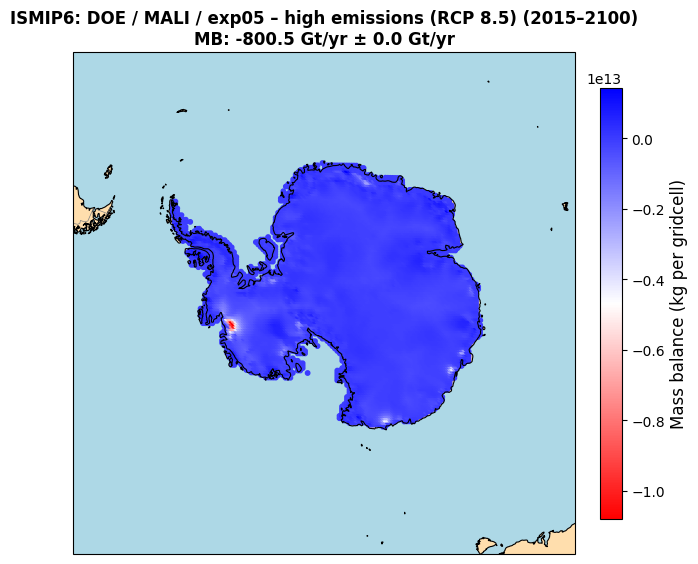

Label(value='')

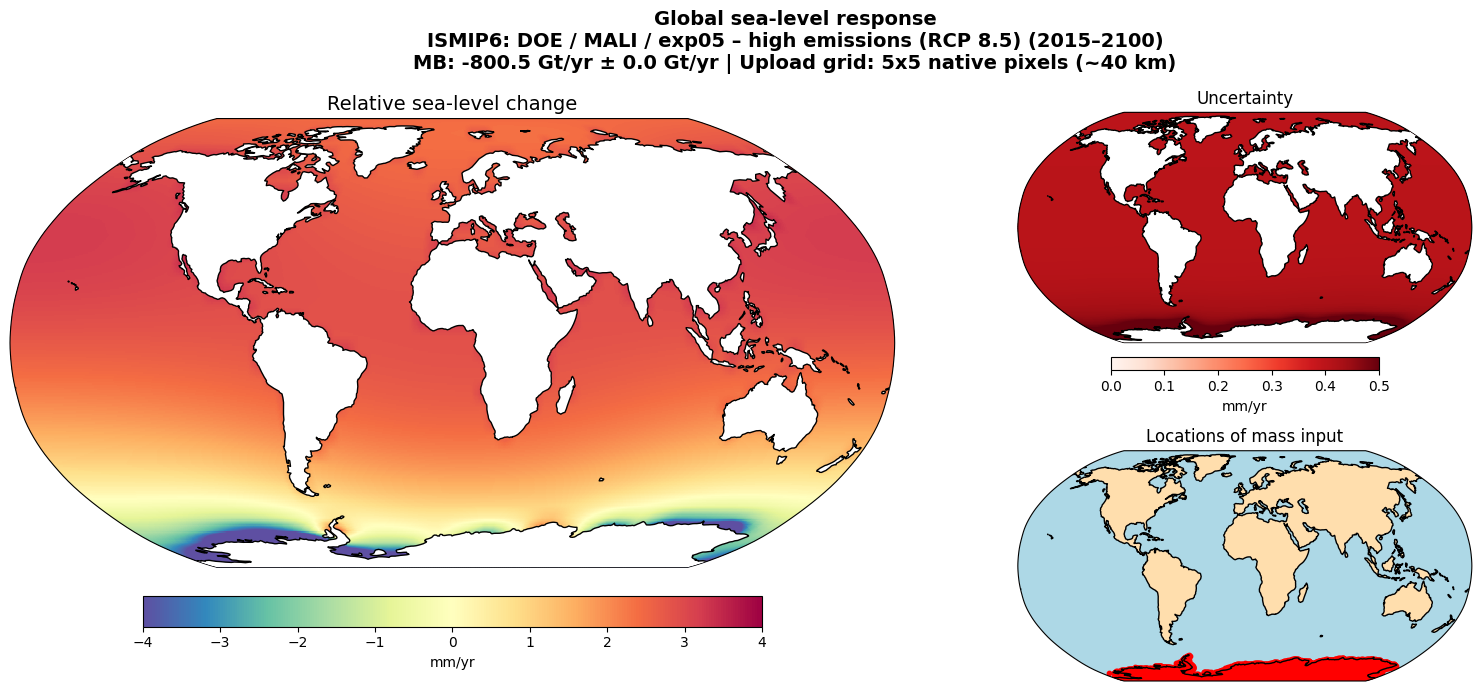

In [12]:
import io as _io

if mass_balance_ds is None or mb_annual is None:
    print("Please load ISMIP6 data first using the cell above.")
else:
    selrem_scale = 1.0
    native_grid_km = 8
    coarsen_factor = 5
    effective_grid_km = coarsen_factor * native_grid_km
    _proj_label = f"{model_dropdown.label} / {experiment_dropdown.label}"

    def _build_upload_mass_balance_ds() -> xr.Dataset:
        """Aggregate native 8 km pixels into 5x5 summed blocks for mass-conserving CSV upload."""
        aggregated_mb_annual = mb_annual.coarsen(y=coarsen_factor, x=coarsen_factor, boundary="trim").sum()
        aggregated_lat = xr.DataArray(lat_2d, dims=("y", "x")).coarsen(
            y=coarsen_factor, x=coarsen_factor, boundary="trim"
        ).mean()
        aggregated_lon = xr.DataArray(lon_2d, dims=("y", "x")).coarsen(
            y=coarsen_factor, x=coarsen_factor, boundary="trim"
        ).mean()

        years = aggregated_mb_annual["time"].dt.year.values
        mb_matrix = aggregated_mb_annual.values.reshape(len(years), -1)
        lat_flat = aggregated_lat.values.reshape(-1)
        lon_flat = aggregated_lon.values.reshape(-1)

        valid_points = (~np.isnan(lat_flat)) & (~np.isnan(lon_flat)) & (~np.all(np.isnan(mb_matrix), axis=0))
        mb_matrix = mb_matrix[:, valid_points]
        lat_flat = lat_flat[valid_points]
        lon_flat = lon_flat[valid_points]
        mb_err_matrix = np.full_like(mb_matrix, np.nan, dtype=float)

        return xr.Dataset(
            {
                MASS_BALANCE_COL_NAME: (("time", "point"), mb_matrix),
                MASS_BALANCE_ERROR_COL_NAME: (("time", "point"), mb_err_matrix),
            },
            coords={
                "time": pd.to_datetime(years, format="%Y"),
                "point": np.arange(mb_matrix.shape[1]),
                "y": ("point", lat_flat),
                "x": ("point", lon_flat),
            },
        )

    upload_mass_balance_ds = _build_upload_mass_balance_ds()
    upload_mean_mb_ds = compute_mean_mass_balance_over_time_window(
        upload_mass_balance_ds, start_time, end_time
    )

    total_mb_gt = float(upload_mean_mb_ds[MASS_BALANCE_COL_NAME].sum()) / 1e12
    total_mb_err_gt = float(upload_mean_mb_ds[MASS_BALANCE_ERROR_COL_NAME].sum(skipna=True)) / 1e12
    mb_str = f"MB: {total_mb_gt:.1f} Gt/yr ± {total_mb_err_gt:.1f} Gt/yr"

    lat_vals = upload_mean_mb_ds["y"].values
    valid_lat_vals = lat_vals[~np.isnan(lat_vals)]
    if np.any(valid_lat_vals < 0) and np.any(valid_lat_vals > 0):
        plot_dataset_value = "AIS and GrIS"
    elif np.any(valid_lat_vals < 0):
        plot_dataset_value = "AIS"
    elif np.any(valid_lat_vals > 0):
        plot_dataset_value = "GrIS"
    else:
        plot_dataset_value = "custom"

    print(
        f"Aggregating native {native_grid_km} km pixels into {coarsen_factor}x{coarsen_factor} "
        f"mass-conserving blocks (~{effective_grid_km} km upload grid)."
    )

    plot_scaled_mean_mass_balance(
        upload_mean_mb_ds,
        dataset_value=plot_dataset_value,
        plot_description_str=f"ISMIP6: {_proj_label} ({start_time.year}–{end_time.year})\n{mb_str}",
        scale=selrem_scale,
    )

    def _mass_balance_ds_to_csv_bytes(ds: xr.Dataset) -> bytes:
        """Serialise mass_balance_ds to API CSV format."""
        lat_vals = ds["y"].values
        lon_vals = ds["x"].values
        years = ds["time"].dt.year.values
        rows = {"lat": lat_vals, "lon": lon_vals}
        for i, yr in enumerate(years):
            rows[f"{yr}_mb"] = ds[MASS_BALANCE_COL_NAME].isel(time=i).values
            rows[f"{yr}_mb_error"] = ds[MASS_BALANCE_ERROR_COL_NAME].isel(time=i).values
        buf = _io.StringIO()
        pd.DataFrame(rows).to_csv(buf, index=False)
        return buf.getvalue().encode("utf-8")

    status_label = widgets.Label(value="")
    display(status_label)

    status_label.value = "⏳ Preparing aggregated mass-balance data for upload..."
    csv_bytes = _mass_balance_ds_to_csv_bytes(upload_mass_balance_ds)
    status_label.value = "⏳ Uploading aggregated mass-balance data to API..."
    dataset_url = upload_mass_balance_csv({"content": csv_bytes, "name": "ismip6_mass_balance_5x5.csv"})

    suptitle = (
        f"Global sea-level response\n"
        f"ISMIP6: {_proj_label} ({start_time.year}–{end_time.year})\n"
        f"{mb_str} | Upload grid: {coarsen_factor}x{coarsen_factor} native pixels (~{effective_grid_km} km)"
    )

    status_label.value = "⏳ Running SELREM module (this may take a few minutes)..."
    global_slr_ds = run_selrem_module(dataset_url, selrem_scale, start_time.year, end_time.year, "global")
    status_label.value = "⏳ Downloading SELREM output..."
    global_slr_ds = global_slr_ds.compute()
    status_label.value = "⏳ Generating plot..."
    plot_global_slr_three_panels(
        global_slr_ds,
        upload_mean_mb_ds,
        plot_description_str=suptitle,
    )
    status_label.value = ""

## Explore the sea-level response at a chosen location

Enter coordinates to investigate the projected sea-level change at any location on the globe.

- **Specify coordinates:** Enter latitude and longitude.
- **Adjust scenario:** Modify the scaling factor to explore amplified/dampened projections.
- **Visualise:** Click **Plot SLR at location** to see the annual time series.

Note that changing the scaling factor requires re-running the SELREM module, which may take
a few minutes.

In [ ]:
lat_input = widgets.FloatText(value=55.7, description="Latitude:", step=0.1)
lon_input = widgets.FloatText(value=12.6, description="Longitude:", step=0.1)
plot_button = widgets.Button(description="Plot SLR at location", button_style="success")

status_label = widgets.Label(value="")
slr_plot_output = widgets.Output()


def on_plot_button_clicked(b: Button) -> None:
    lat0 = lat_input.value
    lon0 = lon_input.value
    with slr_plot_output:
        clear_output(wait=True)
        status_label.value = "⏳ Generating plot..."
        plot_button.disabled = True
        plot_slr_location_four_panels(annual_slr_ds, lat0=lat0, lon0=lon0)
        status_label.value = ""
        plot_button.disabled = False


plot_button.on_click(on_plot_button_clicked)


def on_scale_loc_change(change: dict) -> None:
    global annual_slr_ds
    status_label.value = "⏳ Running SELREM module (this may take a few minutes)..."
    plot_button.disabled = True
    annual_slr_ds = run_selrem_module(
        dataset_url, 1.0, start_time.year, end_time.year, "annual"
    )
    status_label.value = "⏳ Downloading SELREM output..."
    annual_slr_ds = annual_slr_ds.compute()
    status_label.value = ""
    plot_button.disabled = False

plot_button.disabled = True
display(lat_input, lon_input, plot_button, status_label, slr_plot_output)

if dataset_url is None:
    print(
        "Location-specific SELREM step skipped: dataset is in-memory only (no uploaded mass_balance_url)."
    )
else:
    status_label.value = "⏳ Running SELREM module (this may take a few minutes)..."
    annual_slr_ds = run_selrem_module(
        dataset_url, 1.0, start_time.year, end_time.year, "annual"
    )
    status_label.value = "⏳ Downloading SELREM output..."
    annual_slr_ds = annual_slr_ds.compute()
    status_label.value = ""
    plot_button.disabled = False

FloatText(value=55.7, description='Latitude:', step=0.1)

FloatText(value=12.6, description='Longitude:', step=0.1)

Button(button_style='success', description='Plot SLR at location', disabled=True, style=ButtonStyle())

Label(value='')

Output()